# Technical Note P11: SciPy Optimization and Least Squares

**Wook Kang · Revised English edition · Version 1.0.0 · 3 October 2026**

This note connects a mathematical task to a numerical object, an implementation, and evidence about the result. It is an instructional computational document. Demonstration parameters are illustrative unless explicitly stated otherwise.

Run from a fresh kernel in cell order. See [the series README](../README.md) for setup and [editorial and verification notes](../docs/EDITORIAL_NOTES.md) for scope and limitations. The English prose has been reorganized and expanded from the supplied Korean notebook; this is an adapted edition rather than a line-by-line translation.

**Reading question:** What is given, what is unknown, what operation relates them, and what independent check can assess the output?

## Core mathematical structure

$$
\frac{d\mathbf y}{dt}=\mathbf f(t,\mathbf y)
$$

$$
\boxed{
\min_{\mathbf x}\ \Phi(\mathbf x)
}
$$

$$
\boxed{
\min_{\boldsymbol\theta}
\frac12
\|\mathbf r(\boldsymbol\theta)\|_2^2
}
$$

In [1]:
# Reproducible display and scale-aware comparison.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
def scaled_allclose(a, b, rtol=1e-12, atol=None, **kwargs):
    """Compare numerical examples using an absolute tolerance scaled to b."""
    a, b = np.asarray(a), np.asarray(b)
    scale = float(np.max(np.abs(b))) if b.size else 0.0
    if atol is None:
        atol = 1e-14 * max(scale, np.finfo(float).tiny)
    return np.allclose(a, b, rtol=rtol, atol=atol, **kwargs)


## 1. Optimization and root finding

Optimization minimizes an objective; root finding seeks zero residual. A minimum need not have zero objective or fit every observation.

$$
F(x)=0
$$

$$
\min_x \Phi(x)
$$

$$
\nabla\Phi(x)=0
$$

In [2]:
import numpy as np
from scipy import optimize

def phi(x):
    return (x - 3.0)**2 + 1.0

res = optimize.minimize_scalar(phi)

print("x* =", res.x)
print("phi(x*) =", res.fun)
print("success =", res.success)

x* = 3.0
phi(x*) = 1.0
success = True


## 2. Scalar minimization

Minimize_scalar handles a one-variable objective. A bounded search restricts the search interval but does not prove a global minimum of an arbitrary multimodal function.

$$
\Phi(x)
$$

In [3]:
res = optimize.minimize_scalar(
    phi,
    bounds=(0.0, 10.0),
    method="bounded",
)

print(res)

 message: Solution found.
 success: True
  status: 0
     fun: 1.0
       x: 3.0
     nit: 6
    nfev: 6


## 3. Multivariable objectives

Supply a scalar-valued callable and an initial parameter vector. The method's stopping status should be accompanied by feasibility and sensitivity checks.

$$
\mathbf x=
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$

$$
\Phi(\mathbf x)=
(x_1-1)^2
+
2(x_2+2)^2
$$

In [4]:
def phi2(x):
    x1, x2 = x
    return (x1 - 1.0)**2 + 2.0*(x2 + 2.0)**2

res = optimize.minimize(
    phi2,
    x0=[0.0, 0.0],
)

print("x* =", res.x)
print("phi(x*) =", res.fun)
print("success =", res.success)
print("message =", res.message)

x* = [ 0.99999756 -2.00000078]
phi(x*) = 7.138870541490366e-12
success = True
message = Optimization terminated successfully.


## 4. Gradients

An analytic gradient can reduce numerical differentiation work. Check it against an independent directional derivative before relying on it.

$$
\nabla\Phi=
\begin{bmatrix}
2(x_1-1)\\
4(x_2+2)
\end{bmatrix}
$$

In [5]:
def grad_phi2(x):
    x1, x2 = x
    return np.array([
        2.0*(x1 - 1.0),
        4.0*(x2 + 2.0),
    ])

res = optimize.minimize(
    phi2,
    x0=[0.0, 0.0],
    jac=grad_phi2,
    method="BFGS",
)

print("x* =", res.x)
print("jac at solution =", res.jac)

x* = [ 0.99999757 -2.00000077]
jac at solution = [-4.85701907e-06 -3.07500147e-06]


## 5. Hessians

The Hessian describes local curvature for a twice-differentiable objective. Its definiteness supports local classifications under the appropriate stationary-point conditions.

$$
H_{ij}=
\frac{\partial^2\Phi}{\partial x_i\partial x_j}
$$

$$
H=
\begin{bmatrix}
2&0\\
0&4
\end{bmatrix}
$$

In [6]:
def hess_phi2(x):
    return np.array([
        [2.0, 0.0],
        [0.0, 4.0],
    ])

print(hess_phi2([0,0]))
print("eigenvalues =", np.linalg.eigvalsh(hess_phi2([0,0])))

[[2. 0.]
 [0. 4.]]
eigenvalues = [2. 4.]


## 6. Local minima and curvature

A positive-definite Hessian at an unconstrained stationary point gives a strict local minimum. Global optimality requires additional structure or evidence.

$$
\nabla\Phi=0
$$

$$
\boxed{
\text{gradient}
\rightarrow
\text{stationarity}
}
$$

$$
\boxed{
\text{Hessian}
\rightarrow
\text{local curvature}
}
$$

## 7. Bounds

Bounds restrict the feasible parameter domain. An optimum at a bound can be valid or can reveal a weakly identified parameter or inappropriate bound.

$$
D>0
$$

$$
0<h<h_{\max}
$$

In [7]:
def phi_bound(x):
    return (x[0] - 5.0)**2

res = optimize.minimize(
    phi_bound,
    x0=[1.0],
    bounds=[(0.0, 3.0)],
)

print("x* =", res.x)
print("phi =", res.fun)

x* = [3.]
phi = 4.0


$$
\boxed{
\text{optimum}
\neq
\text{necessarily stationary interior point}
}
$$

## 8. Equality constraints

An equality requires the constraint residual to vanish within a justified tolerance. Check the returned constraint value independently of success.

$$
\min_{x,y}
(x-1)^2+(y-2)^2
$$

$$
x+y=1
$$

In [8]:
def objective_xy(z):
    x, y = z
    return (x-1)**2 + (y-2)**2

constraint = {
    "type": "eq",
    "fun": lambda z: z[0] + z[1] - 1.0,
}

res = optimize.minimize(
    objective_xy,
    x0=[0.0, 0.0],
    constraints=[constraint],
    method="SLSQP",
)

print("x* =", res.x)
print("constraint =", constraint["fun"](res.x))

x* = [2.98023251e-09 9.99999997e-01]
constraint = 0.0


## 9. Inequality constraints

For the dictionary interface used here, an inequality is interpreted as its callable being nonnegative. Other interfaces express lower and upper bounds explicitly.

```python
g(x) >= 0
```

$$
x+y\ge1
$$

In [9]:
ineq = {
    "type": "ineq",
    "fun": lambda z: z[0] + z[1] - 1.0,
}

res = optimize.minimize(
    objective_xy,
    x0=[0.0, 0.0],
    constraints=[ineq],
    method="SLSQP",
)

print("x* =", res.x)
print("ineq value =", ineq["fun"](res.x))

x* = [1. 2.]
ineq value = 2.0


## 10. Method families

BFGS treats smooth unconstrained problems; L-BFGS-B adds bounds; SLSQP and trust-constr handle constraints. Supply derivatives and scaling when their cost is justified.

| Method | Features |  
| --- | --- |  
| BFGS | smooth unconstrained |  
| L-BFGS-B | bounds + large variables |  
| Nelder-Mead | derivative-free |  
| Powell | derivative-free |  
| SLSQP | bounds + nonlinear constraints |  
| trust-constr | general constrained |  
| Newton-CG | gradient + Hessian/Hessian-vector |

## 11. Least-squares structure

A residual vector preserves the contribution of each observation. Least_squares exploits this structure rather than accepting only the summed scalar objective.

$$
\mathbf r(\theta)=
\begin{bmatrix}
r_1(\theta)\\
r_2(\theta)\\
\vdots\\
r_m(\theta)
\end{bmatrix}
$$

$$
\Phi(\theta)=
\frac12
\sum_{i=1}^{m}r_i(\theta)^2
$$

$$
\boxed{
\text{least squares}=
\text{residual-vector optimization}
}
$$

## 12. Linear regression through residuals

The residual compares the model with observations at fixed inputs. The teaching example exposes the general nonlinear interface even though a direct linear least-squares solve is available.

$$
y=a+bx
$$

$$
r_i=a+bx_i-y_i
$$

In [10]:
xdata = np.array([0,1,2,3,4], dtype=float)
ydata = np.array([1.1,2.0,3.2,3.9,5.1])

def residual_linear(theta):
    a, b = theta
    return a + b*xdata - ydata

res = optimize.least_squares(
    residual_linear,
    x0=[0.0, 1.0],
)

print("theta* =", res.x)
print("cost =", res.cost)
print("optimality =", res.optimality)
print("success =", res.success)

theta* = [1.08 0.99]
cost = 0.025499999999999932
optimality = 5.471971622325363e-09
success = True


```python
cost
```

$$
\frac12\|\mathbf r\|^2
$$

In [11]:
r = residual_linear(res.x)

print("RSS =", np.sum(r**2))
print("2 * cost =", 2*res.cost)

RSS = 0.05099999999999987
2 * cost = 0.050999999999999865


## 13. Read a least-squares result

Inspect parameters, residuals, Jacobian, gradient, cost, active bounds, and termination message. For linear loss, cost is half the residual sum of squares; robust losses change that relation.

In [12]:
print("x =", res.x)
print("residual vector =", res.fun)
print("Jacobian shape =", res.jac.shape)
print("gradient =", res.grad)
print("nfev =", res.nfev)
print("njev =", res.njev)
print("message =", res.message)

x = [1.08 0.99]
residual vector = [-0.02  0.07 -0.14  0.15 -0.06]
Jacobian shape = (5, 2)
gradient = [ 5.47197162e-09 -2.05459427e-09]
nfev = 3
njev = 3
message = `gtol` termination condition is satisfied.


## 14. Residual Jacobians

Rows identify observations and columns identify parameters. The derivatives should correspond to the same scaled residual used by the optimizer.

$$
J_{ij}=
\frac{\partial r_i}{\partial \theta_j}
$$

$$
J=
\begin{bmatrix}
1&x_1\\
1&x_2\\
\vdots&\vdots
\end{bmatrix}
$$

In [13]:
def jac_linear(theta):
    return np.column_stack([
        np.ones_like(xdata),
        xdata,
    ])

J = jac_linear(res.x)

print(J)
print("rank =", np.linalg.matrix_rank(J))
print("condition =", np.linalg.cond(J))

[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]
rank = 2
condition = 4.738720018687268


## 15. Identifiability

Nearly dependent Jacobian columns indicate locally similar parameter effects. Rank and singular values depend on parameter scaling and experimental design.

$$
\mathbf J
$$

$$
\boxed{
\text{good fit}
\neq
\text{good identifiability}
}
$$

In [14]:
U, s, VT = np.linalg.svd(J, full_matrices=False)

print("singular values =", s)
print("relative singular values =", s/s[0])

singular values = [5.78859314 1.22155205]
relative singular values = [1.         0.21102745]


## 16. Nonlinear exponential fit

Synthetic observations illustrate amplitude and rate estimation. The known generating parameters are teaching references, not a demonstration of predictive validity for wood.

$$
y(t)=A e^{-kt}
$$

$$
\theta=(A,k)
$$

In [15]:
t = np.linspace(0, 5, 30)

A_true = 2.0
k_true = 0.7

rng = np.random.default_rng(1)
yobs = A_true*np.exp(-k_true*t) + 0.03*rng.normal(size=t.size)

def model_exp(theta):
    A, k = theta
    return A*np.exp(-k*t)

def residual_exp(theta):
    return model_exp(theta) - yobs

res_exp = optimize.least_squares(
    residual_exp,
    x0=[1.0, 0.2],
)

print("estimated =", res_exp.x)
print("true =", [A_true, k_true])

estimated = [2.01646131 0.70721389]
true = [2.0, 0.7]


## 17. Bounds in least squares

Positive amplitude and rate constraints can enforce admissibility. They cannot supply information missing from the observations.

```python
bounds=(lower, upper)
```

In [16]:
res_exp_b = optimize.least_squares(
    residual_exp,
    x0=[1.0, 0.2],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
)

print("estimated =", res_exp_b.x)
print("active_mask =", res_exp_b.active_mask)

estimated = [2.01646131 0.7072139 ]
active_mask = [0 0]


## 18. Parameters at bounds

Inspect active_mask and the residual pattern. A bound can conceal a flat objective or compensate for model discrepancy.

$$
\boxed{
\text{best fit lies at feasible-region boundary}
}
$$

## 19. Parameter scaling

Scale trial steps by characteristic parameter values or Jacobian information. Report this choice, especially when parameters have different units.

$$
D\sim10^{-10},
\qquad
h\sim10^{-8}
$$

In [17]:
res_scaled = optimize.least_squares(
    residual_exp,
    x0=[1.0, 0.2],
    x_scale="jac",
)

print("estimated =", res_scaled.x)

estimated = [2.01646131 0.70721389]


## 20. Log parameterization

Writing a positive parameter as a reference scale times exp(eta) gives an unconstrained logarithmic coordinate. Use a dimensionless ratio when taking a physical logarithm.

$$
\eta=\ln\theta
$$

$$
\theta=e^\eta
$$

In [18]:
def residual_log(eta):
    A = np.exp(eta[0])
    k = np.exp(eta[1])
    return A*np.exp(-k*t) - yobs

eta0 = np.log([1.0, 0.2])

res_log = optimize.least_squares(
    residual_log,
    x0=eta0,
)

theta_est = np.exp(res_log.x)

print("estimated physical parameters =", theta_est)

estimated physical parameters = [2.01646131 0.7072139 ]


## 21. Residual scaling

Scale by an explicit noise model or characteristic response, not merely to produce convenient numbers. This determines which observations influence the objective.

$$
\hat r_i=\frac{r_i}{s_i}
$$

## 22. Weighted least squares

Divide residuals by stated standard deviations when a diagonal noise covariance is appropriate. The example weights are illustrative and are not the noise law used to generate its synthetic data.

$$
\Phi(\theta)=
\frac12
\sum_i
\left(
\frac{y_i^{\text{pred}}-y_i^{\text{obs}}}{\sigma_i}
\right)^2
$$

$$
r_i^{(w)}=
\frac{r_i}{\sigma_i}
$$

In [19]:
sigma = 0.02 + 0.02*t/t.max()

def residual_weighted(theta):
    return (model_exp(theta) - yobs)/sigma

res_w = optimize.least_squares(
    residual_weighted,
    x0=[1.0, 0.2],
    bounds=([0,0],[np.inf,np.inf]),
)

print("weighted estimate =", res_w.x)

weighted estimate = [2.01416497 0.70528612]


## 23. Robust losses

Robust losses reduce the influence of large residuals. Choose the transition scale deliberately; they do not establish that an outlier is erroneous or repair a missing mechanism.

In [20]:
yobs_out = yobs.copy()
yobs_out[10] += 0.8

def residual_out(theta):
    A, k = theta
    return A*np.exp(-k*t) - yobs_out

res_plain = optimize.least_squares(
    residual_out,
    [1.0,0.2],
)

res_robust = optimize.least_squares(
    residual_out,
    [1.0,0.2],
    loss="soft_l1",
    f_scale=0.05,
)

print("plain  =", res_plain.x)
print("robust =", res_robust.x)

plain  = [1.99996201 0.6546473 ]
robust = [2.01527255 0.70152057]


## 24. Fit diagnostics

RMSE, MAE, and normalized metrics summarize different errors. Report units and normalization; an undefined or near-zero normalization range needs special handling.

$$
\boxed{
\text{estimate}
+
\text{diagnostics}
}
$$

In [21]:
pred = model_exp(res_exp_b.x)
resid = pred - yobs

rmse = np.sqrt(np.mean(resid**2))
mae = np.mean(np.abs(resid))
nrmse = rmse / (yobs.max() - yobs.min())

print("RMSE =", rmse)
print("MAE =", mae)
print("NRMSE =", nrmse)

RMSE = 0.024410911655677082
MAE = 0.0171322867730781
NRMSE = 0.012320804216317578


## 25. Residual plots

Look for trends, correlated structure, changing spread, and boundary effects. A good scalar metric can hide a systematic model discrepancy.

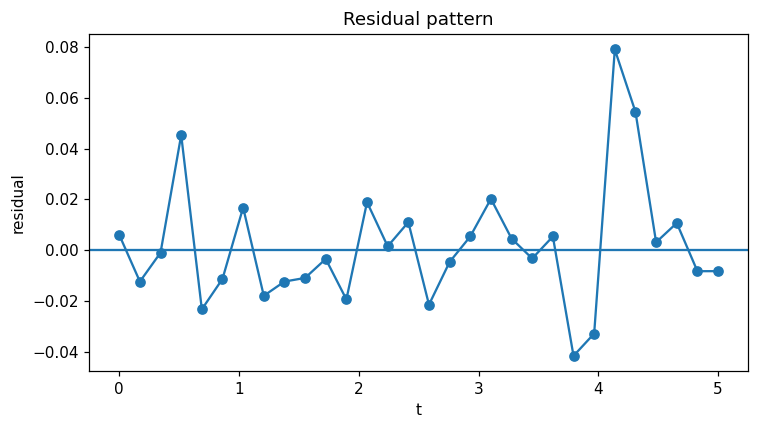

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.axhline(0.0)
plt.plot(t, resid, marker="o")
plt.xlabel("t")
plt.ylabel("residual")
plt.title("Residual pattern")
plt.tight_layout()
plt.show()

## 26. Multiple starts

Compare several starting points and resulting objective values. Agreement improves confidence in a search outcome without proving global optimality or uniqueness.

In [23]:
starts = [
    [0.5,0.1],
    [1.0,1.0],
    [3.0,0.3],
    [5.0,2.0],
]

for x0 in starts:
    r = optimize.least_squares(
        residual_exp,
        x0=x0,
        bounds=([0,0],[np.inf,np.inf]),
    )
    print("x0 =", x0, "->", r.x, "cost =", r.cost)

x0 = [0.5, 0.1] -> [2.01646131 0.7072139 ] cost = 0.008938389117919058
x0 = [1.0, 1.0] -> [2.01646131 0.7072139 ] cost = 0.008938389117919084
x0 = [3.0, 0.3] -> [2.01646132 0.7072139 ] cost = 0.008938389117919292
x0 = [5.0, 2.0] -> [2.01646132 0.7072139 ] cost = 0.00893838911791923


## 27. Interpret optimization success

Success records satisfaction of a stopping rule. It does not establish identifiability, uncertainty calibration, or performance on independent data.

$$
\boxed{
\text{optimizer convergence}
\neq
\text{physical inference success}
}
$$

## 28. Objective surfaces

A two-parameter grid can reveal valleys and parameter tradeoffs. Grid minima approximate a sampled surface rather than proving a continuous optimum.

$$
\Phi(A,k)=
\frac12
\sum_i
r_i(A,k)^2
$$

In [24]:
A_grid = np.linspace(1.4, 2.6, 80)
k_grid = np.linspace(0.4, 1.0, 80)

Phi = np.zeros((len(A_grid), len(k_grid)))

for i, A0 in enumerate(A_grid):
    for j, k0 in enumerate(k_grid):
        rr = A0*np.exp(-k0*t) - yobs
        Phi[i,j] = 0.5*np.sum(rr**2)

print("objective min grid =", Phi.min())

objective min grid = 0.00902015215538648


## 29. Sensitivity and local identifiability

Scale the Jacobian before interpreting singular values or column correlations. Weak directions identify combinations of parameters that the current observations poorly constrain.

$$
J_{ij}=
\frac{\partial r_i}{\partial\theta_j}
$$

$$
c_{ij}=
\frac{J_i^T J_j}
{\|J_i\|\|J_j\|}
$$

In [25]:
J = res_exp_b.jac

col0 = J[:,0]
col1 = J[:,1]

cosine = (col0 @ col1)/(np.linalg.norm(col0)*np.linalg.norm(col1))

svals = np.linalg.svd(J, compute_uv=False)

print("Jacobian shape =", J.shape)
print("column cosine =", cosine)
print("singular values =", svals)
print("condition =", svals[0]/svals[-1])

Jacobian shape = (30, 2)
column cosine = -0.6675343118274796
singular values = [4.31599896 1.49407278]
condition = 2.888747461367546


## 30. Covariance approximations

A local covariance estimate requires a suitable noise model, locally adequate linearization, sufficient rank, and appropriate treatment of constraints. Use QR or SVD rather than forming an ill-conditioned normal inverse.

$$
\operatorname{Cov}(\hat\theta)
\approx
\sigma^2
(J^T J)^{-1}
$$

## 31. Practical identifiability

Profiles, bootstrap analyses, posterior exploration, and new experiments can reveal uncertainty beyond a local Hessian. All depend on additional modeling assumptions.

$$
\boxed{
\text{local Jacobian information}
\neq
\text{global uniqueness proof}
}
$$

## 32. Inverse-problem structure

Parameters enter a forward model, which predicts observations through a measurement operator. The optimizer sees residuals rather than the underlying physical reasoning.

$$
\boxed{
\theta
\rightarrow
\text{forward model}
\rightarrow
y_{\mathrm{pred}}
\rightarrow
r(\theta)
\rightarrow
\text{optimizer}
}
$$

## 33. PDE parameter estimation

Each parameter trial may require a complete PDE solve. Numerical error in that forward solve contaminates the objective and derivative estimates.

$$
D
\rightarrow
\text{PDE solve}
\rightarrow
\bar M(t;D)
\rightarrow
r(D)
\rightarrow
\texttt{least\_squares}
$$

## 34. Computational cost

Finite-difference sensitivities can require many forward runs. Analytic sensitivities, adjoints, and surrogates may help, but their accuracy must also be checked.

## 35. Minimize or least_squares

Use a residual interface when the objective genuinely has least-squares structure. Use a general objective interface for other criteria.

$$
\min_x \Phi(x)
$$

$$
\min_\theta \frac12\|r(\theta)\|^2
$$

## 36. Selection map

Match objective structure, derivatives, bounds, constraints, scaling, and evaluation cost to the method. Decide in advance what evidence counts as an acceptable result.

| Problem | Representative SciPy tool |  
| --- | --- |  
| scalar objective | `minimize_scalar` |  
| smooth unconstrained | `minimize` + BFGS |  
| bounds | L-BFGS-B / SLSQP / trust-constr |  
| nonlinear constraints | SLSQP / trust-constr |  
| nonlinear least squares | `least_squares` |  
| robust regression | `least_squares(loss=...)` |  
| Global search required | Consider `differential_evolution` and related methods |

## 37. Ideas to retain

Separate a fit from a prediction, search convergence from identifiability, and a local uncertainty approximation from a validated predictive interval.

$$
\boxed{
\text{good fit}
\neq
\text{good identifiability}
}
$$

$$
\boxed{
\text{optimizer convergence}
\neq
\text{physical inference success}
}
$$

## 38. Continue to P12

Interpolation, integration, and differentiation connect discrete data to continuous calculations and introduce distinct uncertainty and resolution issues.

$$
\boxed{
\text{solver}
\rightarrow
\text{numerical operators on data/functions}
}
$$

## Supplement: independent numerical checks

These checks target mathematical invariants or an independent reference. They do not validate a wood constitutive law against observations. Tolerances belong to the stated example and tested environment.

In [26]:
# Check independent analytic sensitivity of the synthetic exponential residual.
theta = res_exp_b.x
Afit,kfit=theta
Jan=np.column_stack([np.exp(-kfit*t),-Afit*t*np.exp(-kfit*t)])
direction=np.array([0.4,-0.2])
step=1e-5
jfd=(residual_exp(theta+step*direction)-residual_exp(theta-step*direction))/(2*step)
np.testing.assert_allclose(Jan@direction,jfd,rtol=1e-8,atol=1e-9)
assert res_exp_b.success
assert np.all(theta>0)
assert np.linalg.matrix_rank(Jan)==2
print("Independent directional Jacobian check passed.")
print("Full rank at this fit is a local result; it does not validate wood parameters.")


Independent directional Jacobian check passed.
Full rank at this fit is a local result; it does not validate wood parameters.


## Further work

1. Change one parameter or discretization choice and predict the effect before running.
2. Write the input and output shapes, units, and field locations.
3. Construct a deliberately invalid input and make the calculation report it clearly.
4. Separate an execution check from an accuracy check and from any physical claim.

## Primary documentation

- [SciPy least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)

These are living documentation links. The accompanying requirements and verification report identify the versions actually executed for this edition.

## AI assistance and responsibility

The English adaptation, editorial supplementation, and code review were prepared with AI assistance. Wook Kang retains responsibility for reviewing the explanations, examples, and any subsequent research application. No new experimental validation is claimed.